# Middlebury RCE: Train on Left, Infer on Right

Standard **Restricted Coulomb Energy (RCE)** network: prototype cells with spherical threshold, Euclidean distance.
- **Train** on left image (im0) using pixels inside a user-defined ROI (object) and outside (background).
- **Infer** on right image (im1); show segmentation mask and optional bounding box.

In [1]:
# Auto-reload so edits to RCE/*.py are picked up without kernel restart
%load_ext autoreload
%autoreload 2

# Setup: add project root to path and import
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "middlebury").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import cv2
import numpy as np
import matplotlib.pyplot as plt
from RCE.loader import get_scene_list, load_stereo_pair
from RCE.rce import RCE

## 1. Load Middlebury and select scene

Pick a scene; left (im0) and right (im1) images are loaded. Set `scene_name` to one of the listed scenes.

Available scenes: ['artroom1', 'artroom2', 'curule1', 'curule2', 'curule3', 'skates1', 'skates2', 'skiboots1', 'skiboots2', 'skiboots3']
Left shape: (1080, 1920, 3), Right shape: (1080, 1920, 3)


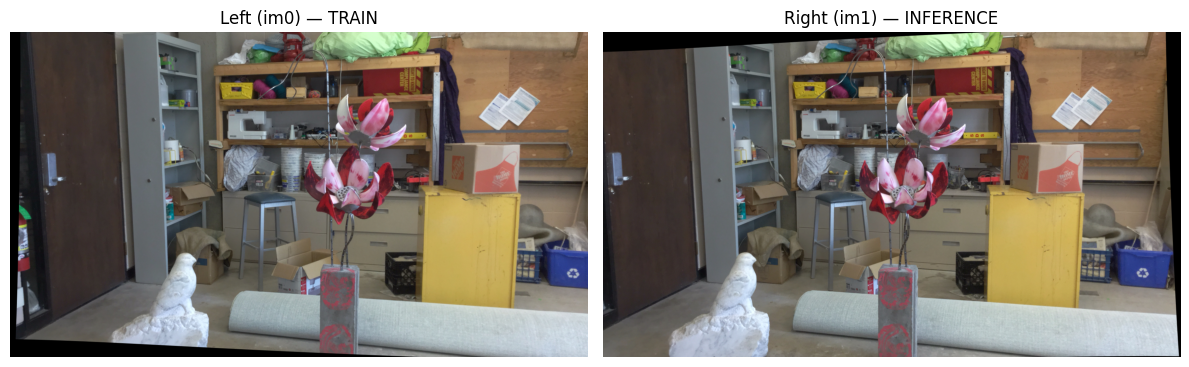

In [2]:
root = PROJECT_ROOT / "data" / "middlebury"
scenes = get_scene_list(root)
print("Available scenes:", scenes)
scene_name = "artroom1"  # change to any scene from the list above
data = load_stereo_pair(root, scene_name)
img_left = data["left"]
img_right = data["right"]
assert img_left is not None and img_right is not None, "Failed to load images"
print(f"Left shape: {img_left.shape}, Right shape: {img_right.shape}")
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(cv2.cvtColor(img_left, cv2.COLOR_BGR2RGB))
ax[0].set_title("Left (im0) — TRAIN")
ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(img_right, cv2.COLOR_BGR2RGB))
ax[1].set_title("Right (im1) — INFERENCE")
ax[1].axis("off")
plt.tight_layout()
plt.show()

## 2. Define object (ROI on left image)

Set rectangle **x, y, width, height** on the left image. Pixels inside = "object", outside = "background". Adjust to enclose the object you want to detect.

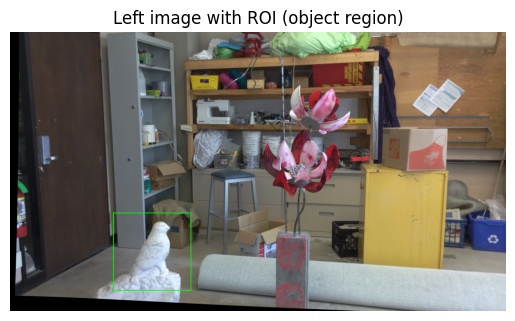

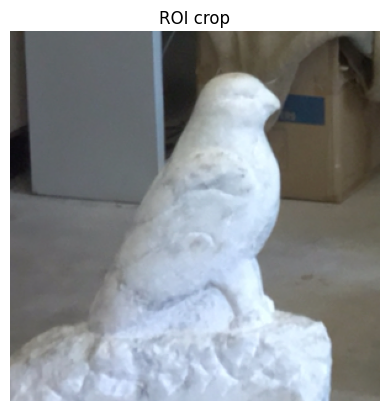

In [3]:
H, W = img_left.shape[:2]
# ROI: (x, y, width, height) — tune these to enclose your object
x, y = 400, 700
w, h = 300, 300
# Clamp to image bounds
x = max(0, min(x, W - 1))
y = max(0, min(y, H - 1))
w = max(1, min(w, W - x))
h = max(1, min(h, H - y))
roi = (x, y, w, h)
vis = img_left.copy()
cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 2)
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title("Left image with ROI (object region)")
plt.axis("off")
plt.show()
# Crop preview
crop = img_left[y : y + h, x : x + w]
plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
plt.title("ROI crop")
plt.axis("off")
plt.show()

## 3. Prepare training data and train RCE

- **Object:** all pixels inside ROI on the left image.
- **Background:** sample of pixels outside ROI (capped for speed).
- Each sample is a 3D RGB vector. Then fit the RCE classifier.

In [4]:
import time

# Object pixels (inside ROI)
obj_pixels = img_left[y : y + h, x : x + w].reshape(-1, 3).astype(np.float64)
n_obj = len(obj_pixels)

# Subsample: RCE commits one prototype per unique region, so we need
# representative coverage, not every pixel.  5k is plenty for 3D colour space.
max_obj = 5_000
rng = np.random.default_rng(42)
if n_obj > max_obj:
    idx = rng.choice(n_obj, max_obj, replace=False)
    obj_pixels = obj_pixels[idx]
    n_obj = len(obj_pixels)
labels_obj = np.array(["object"] * n_obj)

# Background pixels (outside ROI): mask and sample
mask_bg = np.ones((H, W), dtype=bool)
mask_bg[y : y + h, x : x + w] = False
bg_pixels = img_left[mask_bg].astype(np.float64)
n_bg_total = len(bg_pixels)
max_bg = 5_000
if n_bg_total > max_bg:
    idx = rng.choice(n_bg_total, max_bg, replace=False)
    bg_pixels = bg_pixels[idx]
labels_bg = np.array(["background"] * len(bg_pixels))

X_train = np.vstack([obj_pixels, bg_pixels])
y_train = np.concatenate([labels_obj, labels_bg])
print(f"Training samples: object={n_obj}, background={len(bg_pixels)}")

# Train RCE (R_max caps initial prototype radius in 0-255 RGB space)
rce = RCE(R_max=80.0, default_label="background")
t0 = time.perf_counter()
rce.fit(X_train, y_train)
dt = time.perf_counter() - t0
n_proto = len(rce.centers_)
n_obj_proto = int((rce.labels_ == "object").sum())
print(f"Prototypes: total={n_proto}, object={n_obj_proto}, background={n_proto - n_obj_proto}")
print(f"Training time: {dt:.2f}s")

Training samples: object=5000, background=5000
Prototypes: total=2741, object=1447, background=1294
Training time: 0.62s


## 4. Inference on right image

Classify every pixel (or a subsampled grid) on the right image. Build segmentation mask; optionally find largest connected component and its bounding box.

In [5]:
Hr, Wr = img_right.shape[:2]

# Subsample grid for speed (step=2 => every 2nd pixel)
step = 2
rows = np.arange(0, Hr, step)
cols = np.arange(0, Wr, step)
grid_r, grid_c = np.meshgrid(rows, cols, indexing="ij")
pixels_right = img_right[grid_r, grid_c].reshape(-1, 3).astype(np.float64)

print(f"Inference pixels: {len(pixels_right):,}  |  Prototypes: {len(rce.centers_)}")
t0 = time.perf_counter()
pred = rce.predict(pixels_right)
dt = time.perf_counter() - t0
print(f"Inference time: {dt:.2f}s")

mask_flat = pred == "object"
mask_shape = (len(rows), len(cols))
mask_small = mask_flat.reshape(mask_shape)

# Upsample mask to full resolution for visualization
mask_full = cv2.resize(
    mask_small.astype(np.uint8), (Wr, Hr), interpolation=cv2.INTER_NEAREST
)
mask_full = mask_full.astype(bool)
print(f"Object pixels in mask: {mask_full.sum():,} / {Hr * Wr:,}")

Inference pixels: 518,400  |  Prototypes: 2741
Inference time: 9.53s
Object pixels in mask: 342,536 / 2,073,600


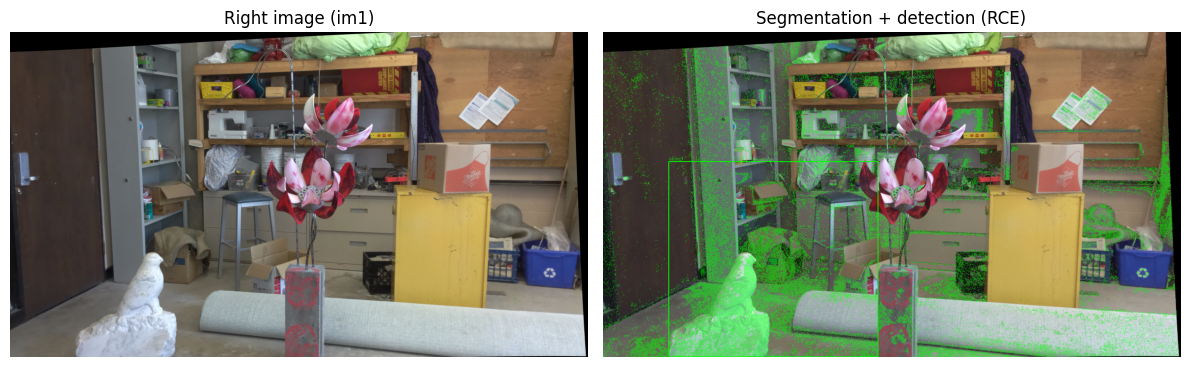

In [6]:
# Overlay: object = green tint
overlay = img_right.copy()
overlay[mask_full] = cv2.addWeighted(
    img_right[mask_full], 0.5,
    np.full_like(img_right[mask_full], (0, 255, 0), dtype=np.uint8), 0.5, 0
)
# Largest connected component and bounding box
num_labels, labels_im = cv2.connectedComponents(mask_full.astype(np.uint8))
if num_labels > 1:
    sizes = [(i, np.sum(labels_im == i)) for i in range(1, num_labels)]
    sizes.sort(key=lambda t: t[1], reverse=True)
    largest_id = sizes[0][0]
    obj_mask = labels_im == largest_id
    ys, xs = np.where(obj_mask)
    if len(xs) > 0 and len(ys) > 0:
        x1, x2 = int(xs.min()), int(xs.max())
        y1, y2 = int(ys.min()), int(ys.max())
        cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(overlay, "object", (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(cv2.cvtColor(img_right, cv2.COLOR_BGR2RGB))
ax[0].set_title("Right image (im1)")
ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
ax[1].set_title("Segmentation + detection (RCE)")
ax[1].axis("off")
plt.tight_layout()
plt.show()

## Summary

Trained on **left (im0)** ROI; inferred on **right (im1)**. Standard RCE: prototype cells with spherical threshold (Euclidean distance); activation when d(x, center) &lt; radius.